In [2]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [27]:
from statsmodels.datasets import get_rdataset

In [28]:
Dataset = get_rdataset("AirPassengers")
Dataset

<class 'statsmodels.datasets.utils.Dataset'>

In [29]:
dir(Dataset)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'clear',
 'copy',
 'data',
 'from_cache',
 'fromkeys',
 'get',
 'items',
 'keys',
 'package',
 'pop',
 'popitem',
 'raw_data',
 'setdefault',
 'title',
 'update',
 'values']

In [30]:
data = Dataset.data
data

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
...,...,...
139,1960.583333,606
140,1960.666667,508
141,1960.750000,461
142,1960.833333,390


## Exploratory Data Analysis

In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    144 non-null    float64
 1   value   144 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [32]:
import pandas as pd

In [33]:
help(pd.date_range)

Help on function date_range in module pandas:

date_range(
    start=None,
    end=None,
    periods=None,
    freq=None,
    tz=None,
    normalize: bool = False,
    name: Hashable | None = None,
    inclusive: IntervalClosedType = 'both',
    *,
    unit: TimeUnit | None = None,
    **kwargs
) -> DatetimeIndex
    Return a fixed frequency DatetimeIndex.

    Returns the range of equally spaced time points (where the difference between any
    two adjacent points is specified by the given frequency) such that they fall in the
    range `[start, end]` , where the first one and the last one are, resp., the first
    and last time points in that range that fall on the boundary of ``freq`` (if given
    as a frequency string) or that are valid for ``freq`` (if given as a
    :class:`pandas.tseries.offsets.DateOffset`). If ``freq`` is positive, the points
    satisfy `start <[=] x <[=] end`, and if ``freq`` is negative, the points satisfy
    `end <[=] x <[=] start`. (If exactly one of ``

In [34]:
Date = pd.date_range("1949-01",periods=len(data),freq='MS')  # "MS"-Month Start Frequency - start of every month
Date

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[us]', length=144, freq='MS')

In [35]:
Date

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[us]', length=144, freq='MS')

In [36]:
data

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
...,...,...
139,1960.583333,606
140,1960.666667,508
141,1960.750000,461
142,1960.833333,390


In [37]:
data['value'].values

array([112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118, 115,
       126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140, 145, 150,
       178, 163, 172, 178, 199, 199, 184, 162, 146, 166, 171, 180, 193,
       181, 183, 218, 230, 242, 209, 191, 172, 194, 196, 196, 236, 235,
       229, 243, 264, 272, 237, 211, 180, 201, 204, 188, 235, 227, 234,
       264, 302, 293, 259, 229, 203, 229, 242, 233, 267, 269, 270, 315,
       364, 347, 312, 274, 237, 278, 284, 277, 317, 313, 318, 374, 413,
       405, 355, 306, 271, 306, 315, 301, 356, 348, 355, 422, 465, 467,
       404, 347, 305, 336, 340, 318, 362, 348, 363, 435, 491, 505, 404,
       359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463, 407,
       362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390,
       432])

In [39]:
passengers = pd.Series(data=data['value'].values,index=Date)

In [40]:
passengers

1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Length: 144, dtype: int64

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
plt.style.use('fivethirtyeight') # style of the plot
plt.rcParams['font.family']='Arial' # font type
plt.rcParams['axes.labelsize'] = 11 # x and y labelsize
plt.rcParams['xtick.labelsize'] = 9 # X tick labelsize
plt.rcParams['ytick.labelsize'] = 9 # y tick labelsize
plt.rcParams['axes.titlesize'] = 14 # title size
plt.rcParams['legend.fontsize']= 12 # Legend font size
plt.rcParams['legend.title_fontsize'] = 14 # Legend title font size
plt.rcParams['lines.linewidth'] = 1.2 # width of the line

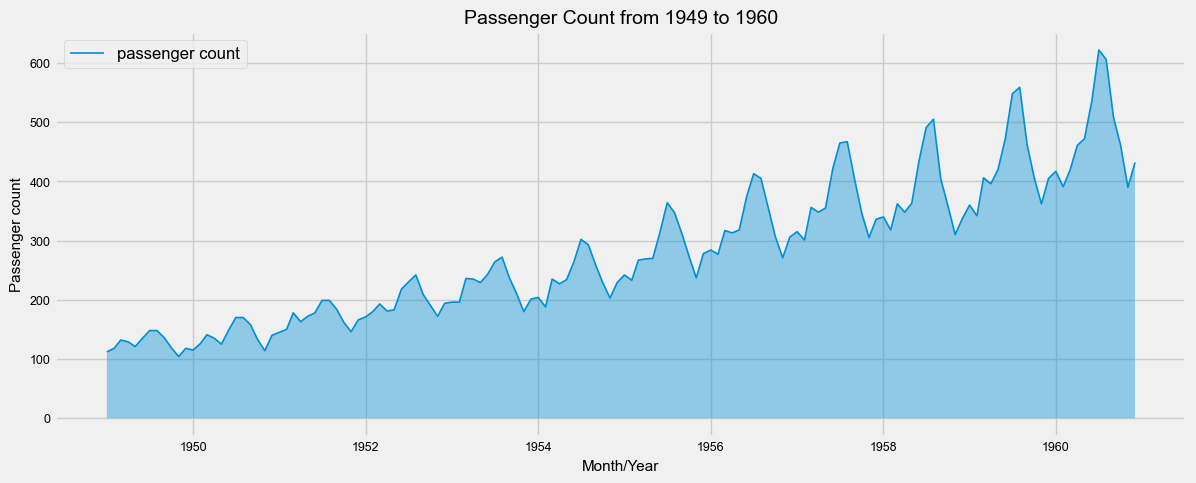

In [58]:
fig, ax = plt.subplots(figsize=(13,5))
sns.lineplot(x=passengers.index , y=passengers.values, label="passenger count")
plt.xlabel('Month/Year')
plt.ylabel('Passenger count')
plt.title('Passenger Count from 1949 to 1960')
ax.fill_between(passengers.index , passengers.values, alpha=0.4)

## Decomposition

In [62]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [63]:
seasonal_decompose?

Signature:
seasonal_decompose(
    x,
    model='additive',
    filt=None,
    period=None,
    two_sided=True,
    extrapolate_trend=0,
)
Docstring:
Seasonal decomposition using moving averages.

Parameters
----------
x : array_like
    Time series. If 2d, individual series are in columns. x must contain 2
    complete cycles.
model : {"additive", "multiplicative"}, optional
    Type of seasonal component. Abbreviations are accepted.
filt : array_like, optional
    The filter coefficients for filtering out the seasonal component.
    The concrete moving average method used in filtering is determined by
    two_sided.
period : int, optional
    Period of the series (e.g., 1 for annual, 4 for quarterly, etc). Must
    be used if x is not a pandas object or if the index of x does not have
    a frequency. Overrides default periodicity of x if x is a pandas
    object with a timeseries index.
two_sided : bool, optional
    The moving average method used in filtering.
    If True (default)

In [65]:
decomposition = seasonal_decompose(x=passengers, model='multiplicative')

In [66]:
decomposition

In [67]:
dir(decomposition)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_observed',
 '_resid',
 '_seasonal',
 '_trend',
 '_weights',
 'nobs',
 'observed',
 'plot',
 'resid',
 'seasonal',
 'trend',
 'weights']

In [70]:
dec_observed = decomposition.observed
dec_observed

1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
1949-04-01    129.0
1949-05-01    121.0
              ...  
1960-08-01    606.0
1960-09-01    508.0
1960-10-01    461.0
1960-11-01    390.0
1960-12-01    432.0
Freq: MS, Length: 144, dtype: float64

Text(0.5, 0, 'Month/Year')

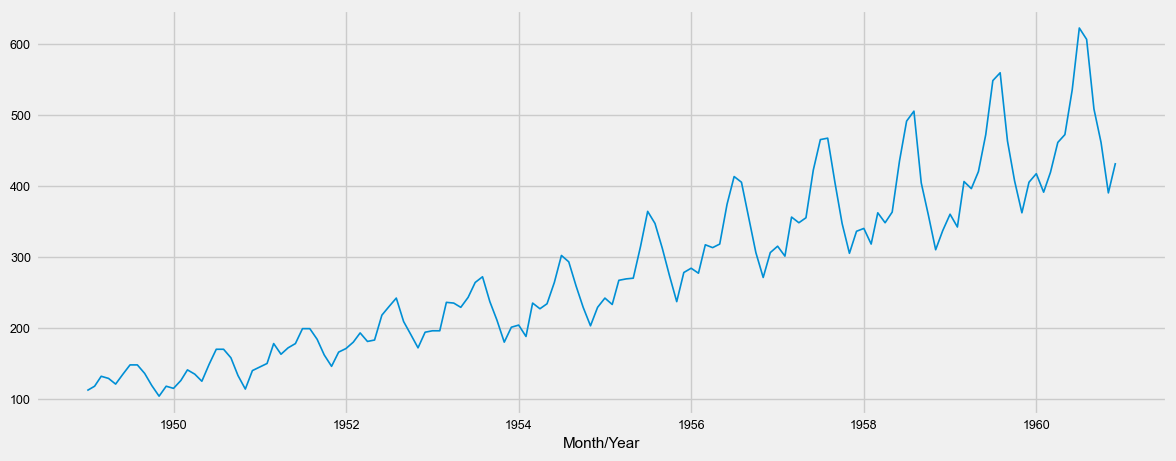

In [75]:
fig, ax = plt.subplots(figsize=(13,5))
sns.lineplot(x=dec_observed.index, y=dec_observed.values)
plt.xlabel('Month/Year')

Text(0.5, 0, 'Month/Year')

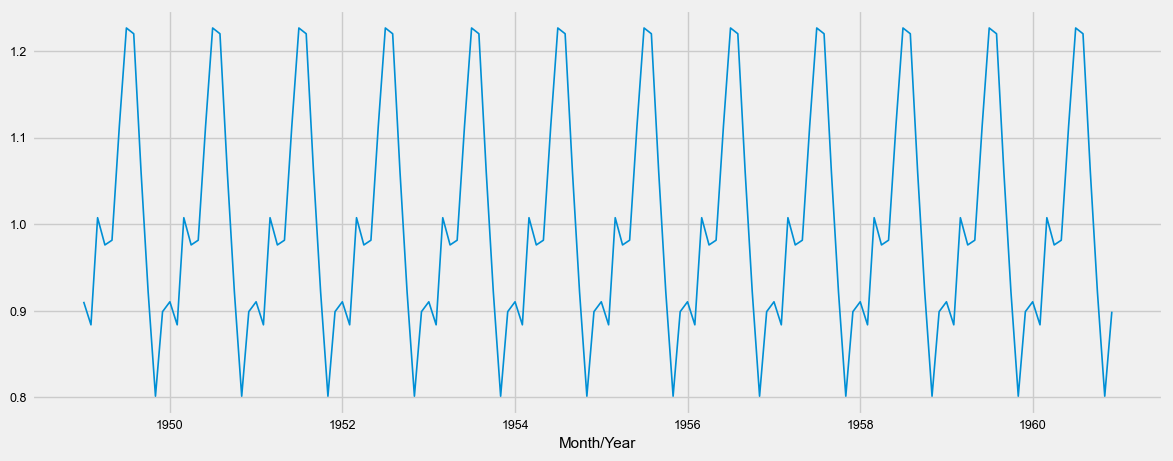

In [76]:
fig, ax = plt.subplots(figsize=(13,5))
sns.lineplot(x=decomposition.seasonal.index, y=decomposition.seasonal.values)
plt.xlabel('Month/Year')

Text(0.5, 0, 'Month/Year')

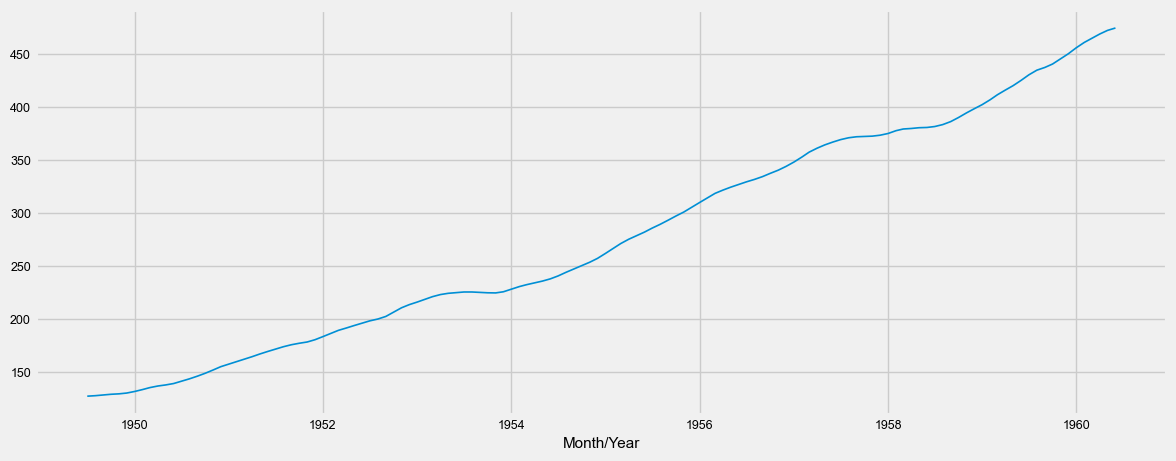

In [77]:
fig, ax = plt.subplots(figsize=(13,5))
sns.lineplot(x=decomposition.trend.index, y=decomposition.trend.values)
plt.xlabel('Month/Year')

Text(0.5, 0, 'Month/Year')

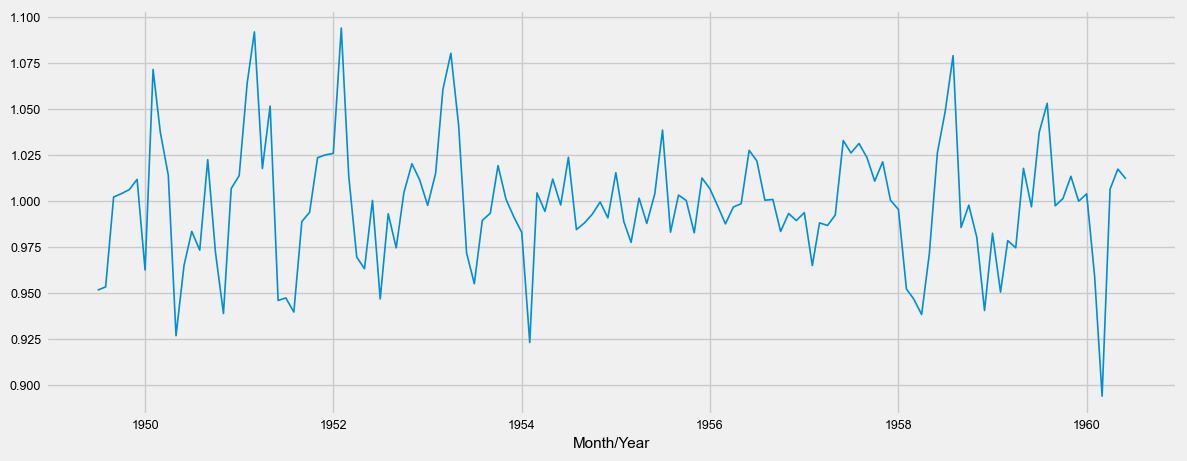

In [78]:
fig, ax = plt.subplots(figsize=(13,5))
sns.lineplot(x=decomposition.resid.index, y=decomposition.resid.values)
plt.xlabel('Month/Year')

## Checking for Stationarity

In [80]:
from statsmodels.tsa.stattools import adfuller

In [81]:
adfuller?

Signature:
adfuller(
    x,
    maxlag: 'int | None' = None,
    regression='c',
    autolag='AIC',
    store=False,
    regresults=False,
)
Docstring:
Augmented Dickey-Fuller unit root test.

The Augmented Dickey-Fuller test can be used to test for a unit root in a
univariate process in the presence of serial correlation.

Parameters
----------
x : array_like, 1d
    The data series to test.
maxlag : {None, int}
    Maximum lag which is included in test, default value of
    12*(nobs/100)^{1/4} is used when ``None``.
regression : {"c","ct","ctt","n"}
    Constant and trend order to include in regression.

    * "c" : constant only (default).
    * "ct" : constant and trend.
    * "ctt" : constant, and linear and quadratic trend.
    * "n" : no constant, no trend.

autolag : {"AIC", "BIC", "t-stat", None}
    Method to use when automatically determining the lag length among the
    values 0, 1, ..., maxlag.

    * If "AIC" (default) or "BIC", then the number of lags is chosen
      to 

In [82]:
stationarity_results = adfuller(x=passengers)

In [84]:
stationarity_results

(np.float64(0.8153688792060482),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [86]:
p_value = stationarity_results[1]
p_value

np.float64(0.991880243437641)

As the **p_value is 0.05** our **time-series data is not-stationarity**

## Converting Non-stationarity into stationary series

### Converting multiplicative effect into addictive

In [87]:
# log(x * y) = log(x) + log(y)

In [88]:
import numpy as np

In [89]:
passengers_log = np.log(passengers)

Text(0.5, 0, 'Month/Year')

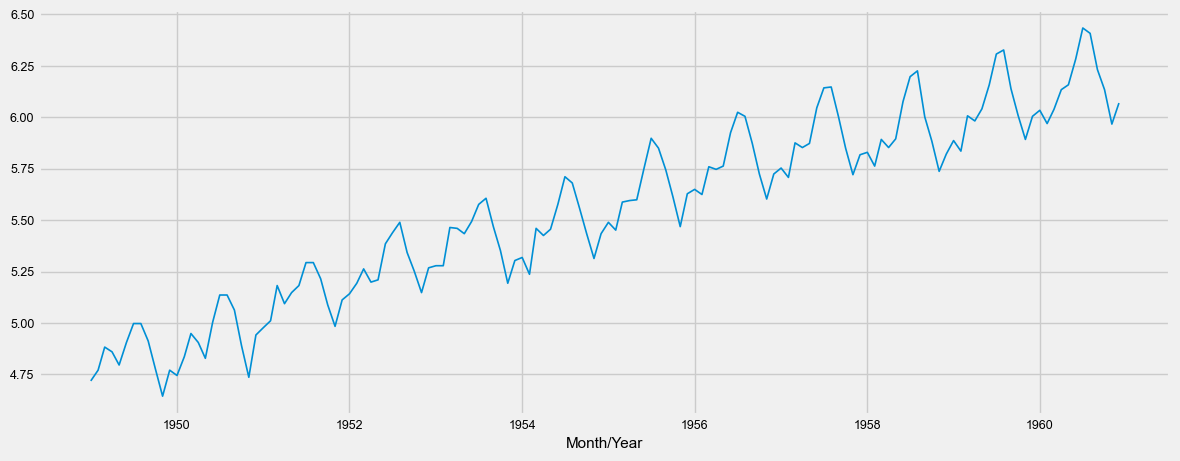

In [91]:
fig, ax = plt.subplots(figsize=(13,5))
sns.lineplot(x=passengers_log.index, y=passengers_log.values)
plt.xlabel('Month/Year')

### Removing Seasonality

In [92]:
seasonality_removed = passengers_log.diff(12)
seasonality_removed

1949-01-01         NaN
1949-02-01         NaN
1949-03-01         NaN
1949-04-01         NaN
1949-05-01         NaN
                ...   
1960-08-01    0.080731
1960-09-01    0.092754
1960-10-01    0.124585
1960-11-01    0.074503
1960-12-01    0.064539
Freq: MS, Length: 144, dtype: float64

Text(0.5, 0, 'Month/Year')

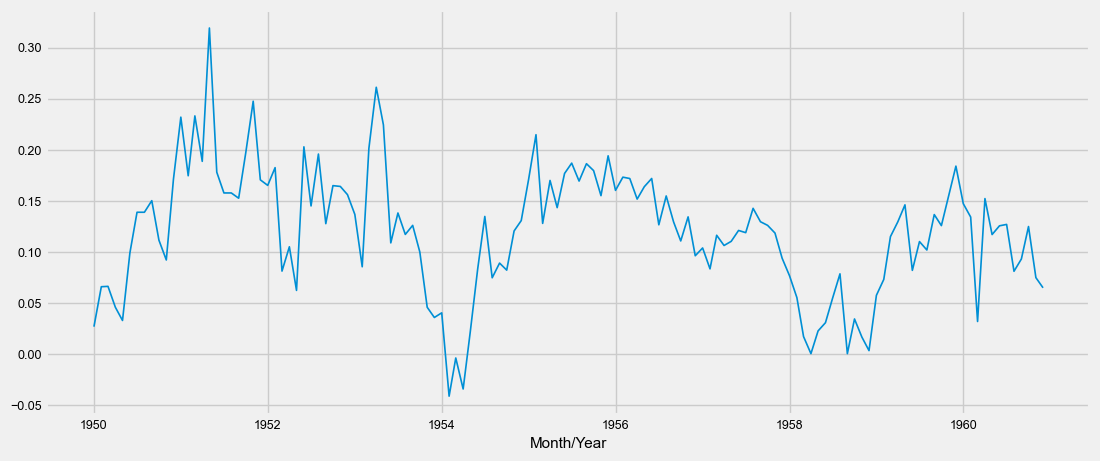

In [96]:
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x=seasonality_removed.index, y=seasonality_removed.values)
plt.xlabel('Month/Year')

### Removing Trend

In [97]:
trend_removed = seasonality_removed.diff(1).dropna()

In [98]:
trend_removed

1950-02-01    0.039164
1950-03-01    0.000361
1950-04-01   -0.020496
1950-05-01   -0.012939
1950-06-01    0.066148
                ...   
1960-08-01   -0.045934
1960-09-01    0.012024
1960-10-01    0.031830
1960-11-01   -0.050082
1960-12-01   -0.009964
Freq: MS, Length: 131, dtype: float64

Text(0.5, 0, 'Month/Year')

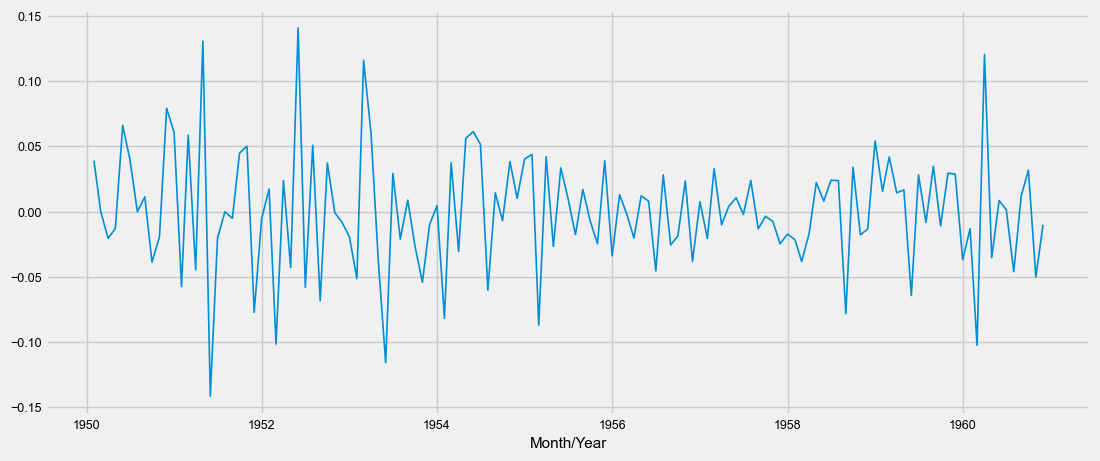

In [99]:
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x=trend_removed.index, y=trend_removed.values)
plt.xlabel('Month/Year')

In [102]:
stationarity_results = adfuller(x=trend_removed)

In [103]:
stationarity_results

(np.float64(-4.4433249418311185),
 np.float64(0.00024859123113840924),
 12,
 118,
 {'1%': np.float64(-3.4870216863700767),
  '5%': np.float64(-2.8863625166643136),
  '10%': np.float64(-2.580009026141913)},
 np.float64(-415.5597525461335))

In [104]:
p_value = stationarity_results[1]
p_value

np.float64(0.00024859123113840924)

as the ***p_value is <0.05***,our ***series is stationary***

## Autocorrelation Plots: ACF,PACF

In [106]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

In [107]:
plot_pacf?

Signature:
plot_pacf(
    x,
    ax=None,
    lags=None,
    alpha=0.05,
    method='ywm',
    use_vlines=True,
    title='Partial Autocorrelation',
    zero=True,
    vlines_kwargs=None,
    **kwargs,
)
Docstring:
Plot the partial autocorrelation function

Parameters
----------
x : array_like
    Array of time-series values
ax : AxesSubplot, optional
    If given, this subplot is used to plot in instead of a new figure being
    created.
lags : {int, array_like}, optional
    An int or array of lag values, used on horizontal axis. Uses
    np.arange(lags) when lags is an int.  If not provided,
    ``lags=np.arange(len(corr))`` is used.
alpha : float, optional
    If a number is given, the confidence intervals for the given level are
    returned. For instance if alpha=.05, 95 % confidence intervals are
    returned where the standard deviation is computed according to
    1/sqrt(len(x))
method : str
    Specifies which method for the calculations to use:

    - "ywm" or "ywmle" : Yule

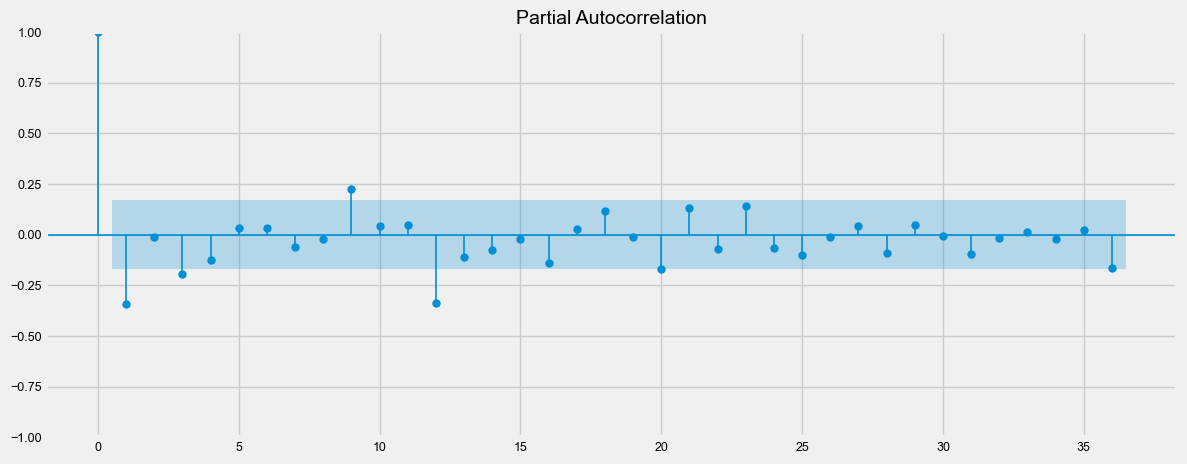

In [111]:
fig, ax = plt.subplots(figsize=(13,5))
plot_pacf(x=trend_removed, lags=36, ax=ax); 

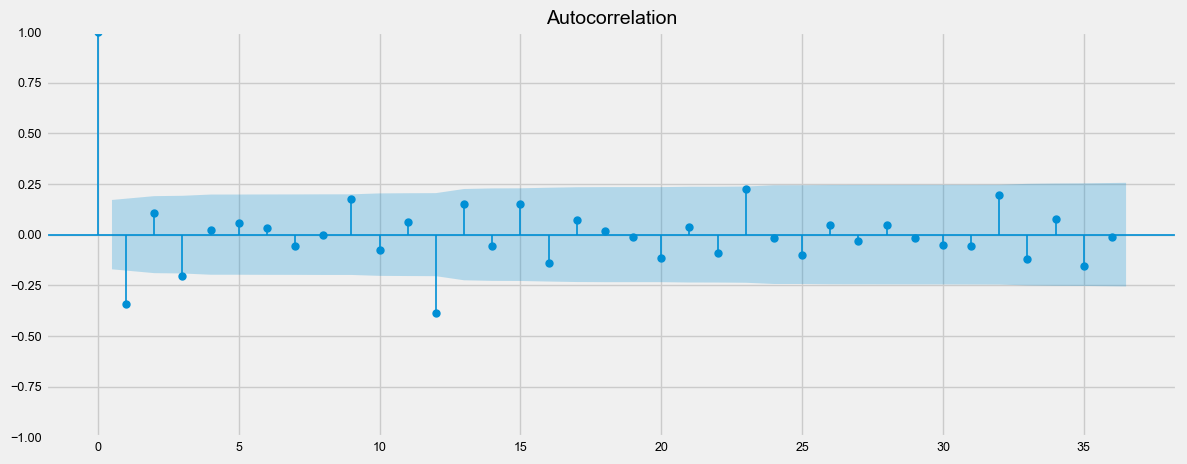

In [112]:
fig, ax = plt.subplots(figsize=(13,5))
plot_acf(x=trend_removed, lags=36, ax=ax);

## Building the Model

### AR Model (AutoRegressive model)

In [113]:
from statsmodels.tsa.arima.model import ARIMA

In [115]:
ARIMA?

Init signature:
ARIMA(
    endog,
    exog=None,
    order=(0, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend=None,
    enforce_stationarity=True,
    enforce_invertibility=True,
    concentrate_scale=False,
    trend_offset=1,
    dates=None,
    freq=None,
    missing='none',
    validate_specification=True,
)
Docstring:     
Autoregressive Integrated Moving Average (ARIMA) model, and extensions

This model is the basic interface for ARIMA-type models, including those
with exogenous regressors and those with seasonal components. The most
general form of the model is SARIMAX(p, d, q)x(P, D, Q, s). It also allows
all specialized cases, including

- autoregressive models: AR(p)
- moving average models: MA(q)
- mixed autoregressive moving average models: ARMA(p, q)
- integration models: ARIMA(p, d, q)
- seasonal models: SARIMA(P, D, Q, s)
- regression with errors that follow one of the above ARIMA-type models

Parameters
----------
endog : array_like, optional
    The observed time-se

In [118]:
AR_model = ARIMA(passengers_log, order=(1,1,0))
AR_model

In [119]:
dir(AR_model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_kwargs',
 '_clone_from_init_kwds',
 '_conditional_sum_squares',
 '_data_attr',
 '_fit_collinear',
 '_fit_zeros',
 '_fixed_params',
 '_fixed_params_index',
 '_forecasts_error_partial_derivatives',
 '_formula_max_endog',
 '_free_params_index',
 '_get_exog_names',
 '_get_extension_time_varying_matrices',
 '_get_index_label_loc',
 '_get_index_loc',
 '_get_index_with_final_state',
 '_get_init_kwds',
 '_get_model_names',
 '_get_prediction_index',
 '_handle_data',
 '_has_fixed_params',
 '_hessian_complex_step',
 '_hessian_finit

In [122]:
AR_model_results = AR_model.fit()

In [123]:
AR_model_results

In [124]:
AR_model_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 120.299
Date:                Sun, 29 Mar 2026   AIC                           -236.598
Time:                        11:53:01   BIC                           -230.672
Sample:                    01-01-1949   HQIC                          -234.190
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2054      0.093      2.204      0.028       0.023       0.388
sigma2         0.0109      0.002      6.050      0.000       0.007       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 6.19
Prob(Q):                              0.71   Prob(JB):                         0.05
Heteroskedasticity (H):               1.16   Skew:                             0.19
Prob(H) (two-sided):                  0.60   Kurtosis:                         2.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### MA (moving averge) Model

In [126]:
MA_model = ARIMA(passengers_log, order=(1,1,0))
MA_model_result = MA_model.fit()
MA_model_result

In [127]:
MA_model_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 120.299
Date:                Sun, 29 Mar 2026   AIC                           -236.598
Time:                        11:55:42   BIC                           -230.672
Sample:                    01-01-1949   HQIC                          -234.190
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2054      0.093      2.204      0.028       0.023       0.388
sigma2         0.0109      0.002      6.050      0.000       0.007       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 6.19
Prob(Q):                              0.71   Prob(JB):                         0.05
Heteroskedasticity (H):               1.16   Skew:                             0.19
Prob(H) (two-sided):                  0.60   Kurtosis:                         2.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### ARIMA Model

In [128]:
ARIMA_model = ARIMA(passengers_log, order=(1,1,0))
ARIMA_model_result = ARIMA_model.fit()
ARIMA_model_result

In [129]:
ARIMA_model_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 120.299
Date:                Sun, 29 Mar 2026   AIC                           -236.598
Time:                        11:58:20   BIC                           -230.672
Sample:                    01-01-1949   HQIC                          -234.190
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2054      0.093      2.204      0.028       0.023       0.388
sigma2         0.0109      0.002      6.050      0.000       0.007       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 6.19
Prob(Q):                              0.71   Prob(JB):                         0.05
Heteroskedasticity (H):               1.16   Skew:                             0.19
Prob(H) (two-sided):                  0.60   Kurtosis:                         2.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Sarimax Model

In [136]:
SARIMAX_model = ARIMA(passengers_log, order=(1,1,1),seasonal_order=(1,1,1,12))
SARIMAX_model_result = SARIMAX_model.fit()
SARIMAX_model_result

In [137]:
SARIMAX_model_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                                y   No. Observations:                  144
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 245.152
Date:                          Sun, 29 Mar 2026   AIC                           -480.303
Time:                                  12:06:32   BIC                           -465.927
Sample:                              01-01-1949   HQIC                          -474.462
                                   - 12-01-1960                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1720      0.212      0.809      0.418      -0.244       0.588
ma.L1         -0.5661      0.184     -3.079      0.002      -0.926      -0.206
ar.S.L12      -0.0973      0.197     -0.494      0.622      -0.484       0.289
ma.S.L12      -0.4989      0.210     -2.375      0.018      -0.911      -0.087
sigma2         0.0013      0.000      8.453      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 3.53
Prob(Q):                              0.90   Prob(JB):                         0.17
Heteroskedasticity (H):               0.61   Skew:                            -0.01
Prob(H) (two-sided):                  0.11   Kurtosis:                         3.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Train Test

In [138]:
train = passengers_log[:120]
test = passengers_log[120:]

In [139]:
train.head()

1949-01-01    4.718499
1949-02-01    4.770685
1949-03-01    4.882802
1949-04-01    4.859812
1949-05-01    4.795791
Freq: MS, dtype: float64

In [140]:
train.tail()

1958-08-01    6.224558
1958-09-01    6.001415
1958-10-01    5.883322
1958-11-01    5.736572
1958-12-01    5.820083
Freq: MS, dtype: float64

In [141]:
test.head()

1959-01-01    5.886104
1959-02-01    5.834811
1959-03-01    6.006353
1959-04-01    5.981414
1959-05-01    6.040255
Freq: MS, dtype: float64

In [142]:
test.tail()

1960-08-01    6.406880
1960-09-01    6.230481
1960-10-01    6.133398
1960-11-01    5.966147
1960-12-01    6.068426
Freq: MS, dtype: float64

## Forecasting

In [146]:
optimal_model = ARIMA(train, order=(1,1,1),seasonal_order=(1,1,1,12))
optimal_model

In [147]:
optimal_model_results = optimal_model.fit()
optimal_model_results

In [150]:
forcast = optimal_model_results.forecast(steps=36)

In [151]:
forcast

1959-01-01    5.856382
1959-02-01    5.809064
1959-03-01    5.955171
1959-04-01    5.928033
1959-05-01    5.955296
1959-06-01    6.124565
1959-07-01    6.236485
1959-08-01    6.243772
1959-09-01    6.070696
1959-10-01    5.937633
1959-11-01    5.800880
1959-12-01    5.901373
1960-01-01    5.928529
1960-02-01    5.878322
1960-03-01    6.022928
1960-04-01    5.994829
1960-05-01    6.023179
1960-06-01    6.193303
1960-07-01    6.305898
1960-08-01    6.314716
1960-09-01    6.137959
1960-10-01    6.005998
1960-11-01    5.868509
1960-12-01    5.967754
1961-01-01    5.995582
1961-02-01    5.945587
1961-03-01    6.090304
1961-04-01    6.062275
1961-05-01    6.090546
1961-06-01    6.260607
1961-07-01    6.373152
1961-08-01    6.381857
1961-09-01    6.205371
1961-10-01    6.073329
1961-11-01    5.935894
1961-12-01    6.035231
Freq: MS, Name: predicted_mean, dtype: float64

In [152]:
optimal_model_results.get_forecast?

Signature: optimal_model_results.get_forecast(steps=1, signal_only=False, **kwargs)
Docstring:
Out-of-sample forecasts and prediction intervals

Parameters
----------
steps : int, str, or datetime, optional
    If an integer, the number of steps to forecast from the end of the
    sample. Can also be a date string to parse or a datetime type.
    However, if the dates index does not have a fixed frequency, steps
    must be an integer. Default is 1.
signal_only : bool, optional
    Whether to compute forecasts of only the "signal" component of
    the observation equation. Default is False. For example, the
    observation equation of a time-invariant model is
    :math:`y_t = d + Z \alpha_t + \varepsilon_t`, and the "signal"
    component is then :math:`Z \alpha_t`. If this argument is set to
    True, then forecasts of the "signal" :math:`Z \alpha_t` will be
    returned. Otherwise, the default is for forecasts of :math:`y_t`
    to be returned.
**kwargs
    Additional arguments may 

In [153]:
prediction_interval = optimal_model_results.get_forecast(steps=36)
prediction_interval

In [154]:
dir(prediction_interval)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_df',
 '_predicted_mean',
 '_row_labels',
 '_use_pandas',
 '_var_pred_mean',
 '_wrap_pandas',
 'conf_int',
 'dist',
 'dist_args',
 'information_set',
 'model',
 'predicted_mean',
 'prediction_results',
 'row_labels',
 'se_mean',
 'signal_only',
 'summary_frame',
 't_test',
 'tvalues',
 'var_pred_mean']

In [156]:
prediction_interval.summary_frame()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
1959-01-01,5.856382,0.037341,5.783194,5.929570
1959-02-01,5.809064,0.044784,5.721288,5.896840
1959-03-01,5.955171,0.049999,5.857176,6.053166
1959-04-01,5.928033,0.054520,5.821176,6.034890
1959-05-01,5.955296,0.058658,5.840329,6.070264
1959-06-01,6.124565,0.062516,6.002035,6.247094
1959-07-01,6.236485,0.066149,6.106836,6.366134
1959-08-01,6.243772,0.069591,6.107375,6.380169
1959-09-01,6.070696,0.072872,5.927870,6.213521
1959-10-01,5.937633,0.076010,5.788656,6.086611


In [157]:
prediction_ci_results = prediction_interval.summary_frame()
prediction_ci_results

y,mean,mean_se,mean_ci_lower,mean_ci_upper
1959-01-01,5.856382,0.037341,5.783194,5.929570
1959-02-01,5.809064,0.044784,5.721288,5.896840
1959-03-01,5.955171,0.049999,5.857176,6.053166
1959-04-01,5.928033,0.054520,5.821176,6.034890
1959-05-01,5.955296,0.058658,5.840329,6.070264
1959-06-01,6.124565,0.062516,6.002035,6.247094
1959-07-01,6.236485,0.066149,6.106836,6.366134
1959-08-01,6.243772,0.069591,6.107375,6.380169
1959-09-01,6.070696,0.072872,5.927870,6.213521
1959-10-01,5.937633,0.076010,5.788656,6.086611


In [158]:
lower_bound = prediction_ci_results['mean_ci_lower']
upper_bound = prediction_ci_results['mean_ci_upper']

## Converting Values back to original scale

In [160]:
trian_original = np.exp(train)
test_original = np.exp(test)
forecast_original = np.exp(forcast)
lower_bound_original = np.exp(lower_bound)
upper_bound_original = np.exp(upper_bound)


## Plotting the Forecast

Text(0.5, 1.0, 'Prediction Performance of SARIMAX Model')

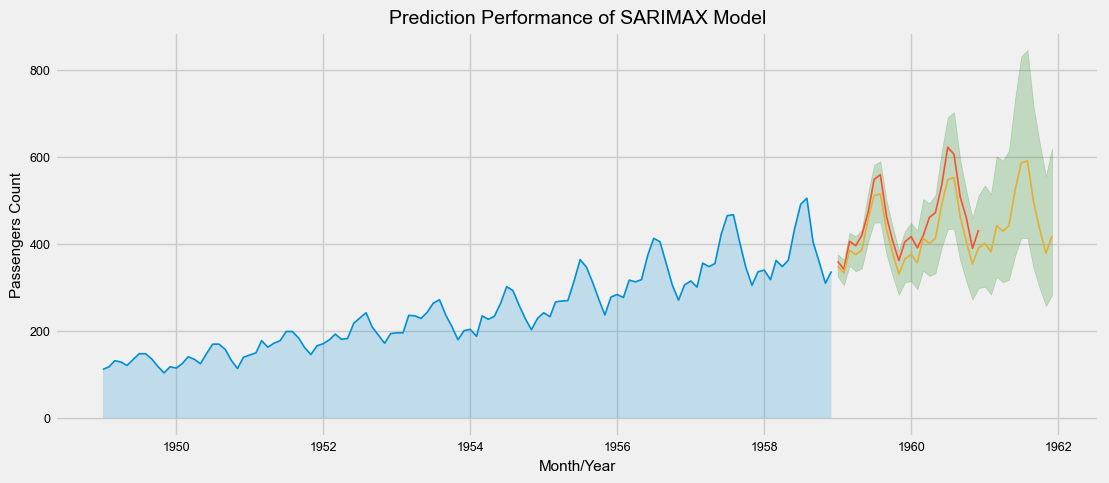

In [170]:
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x=trian_original.index, y=trian_original.values)
sns.lineplot(x=test_original.index, y=test_original.values)
sns.lineplot(x=forecast_original.index, y=forecast_original.values)
ax.fill_between(forecast_original.index, lower_bound_original, upper_bound_original, alpha=0.2, color='green', label='Prediction Interval')
ax.fill_between(trian_original.index, trian_original.values, alpha=0.2)
plt.xlabel("Month/Year")
plt.ylabel("Passengers Count")
plt.title("Prediction Performance of SARIMAX Model")